# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)

In [3]:
# Cài đặt thư viện
!pip install opencv-python -q

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as hnat
from sklearn.cluster import KMeans
from skimage import filters, segmentation, color
from skimage import graph
import warnings
warnings.filterwarnings('ignore')

# Hàm đọc ảnh theo yêu cầu nộp bài
img  = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

# Chuyển sang RGB để hiển thị
img_rgb  = cv2.cvtColor(img,  cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Ảnh grayscale
gray  = cv2.cvtColor(img,  cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print('Đọc ảnh thành công!')
print(f'Kích thước hinh1: {img.shape}')
print(f'Kích thước hinh2: {img2.shape}')

Đọc ảnh thành công!
Kích thước hinh1: (650, 1280, 3)
Kích thước hinh2: (1602, 1200, 3)


---
## 1. Thresholding để phân đoạn ảnh

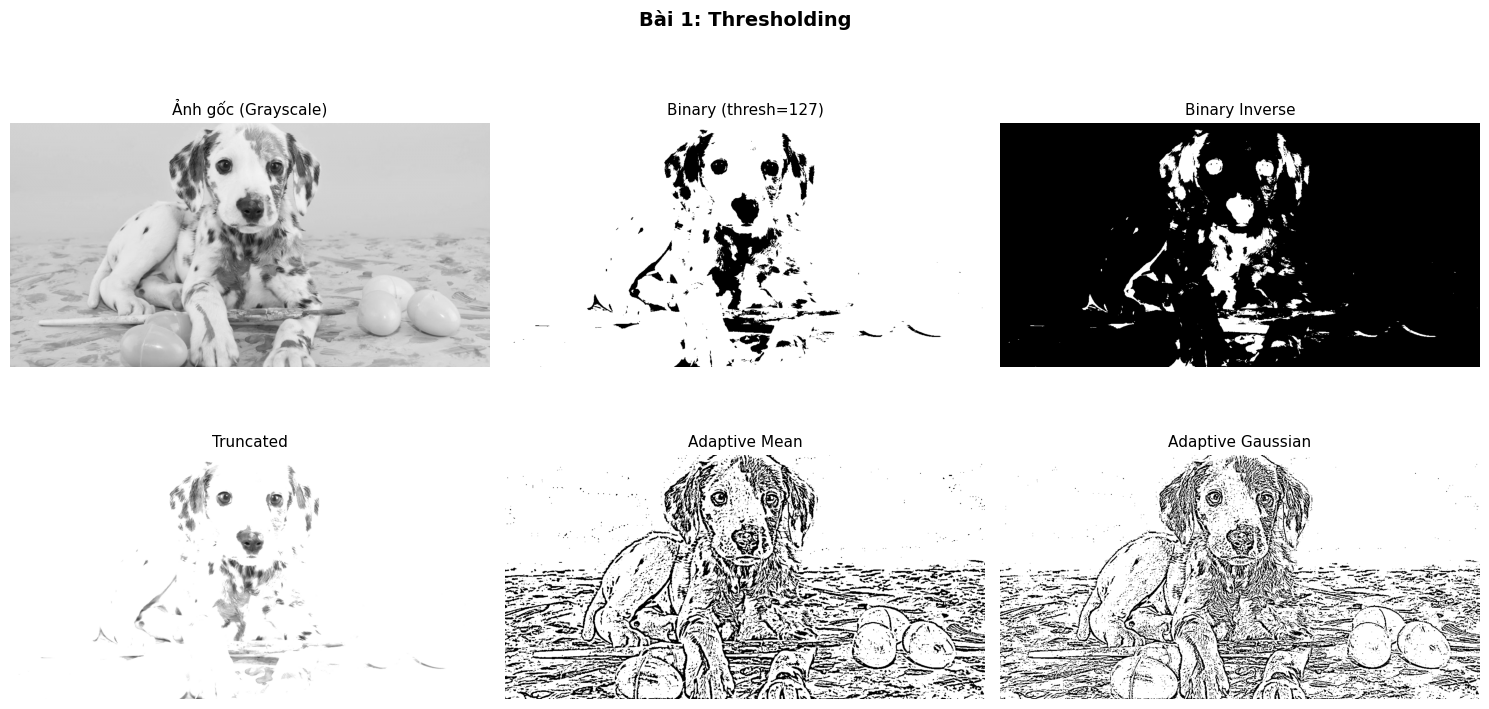

In [5]:
# Phân đoạn ảnh bằng các phương pháp ngưỡng

# 1. Binary Thresholding (ngưỡng thủ công = 127)
_, thresh_binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2. Binary Inverse Thresholding
_, thresh_binary_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 3. Truncated Thresholding
_, thresh_trunc = cv2.threshold(gray, 127, 255, cv2.THRESH_TRUNC)

# 4. Adaptive Mean Thresholding
thresh_adaptive_mean = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize=11, C=2
)

# 5. Adaptive Gaussian Thresholding
thresh_adaptive_gauss = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11, C=2
)

# Hiển thị kết quả
hnat.figure(figsize=(15, 8))

titles = ['Ảnh gốc (Grayscale)',
          'Binary (thresh=127)',
          'Binary Inverse',
          'Truncated',
          'Adaptive Mean',
          'Adaptive Gaussian']
images = [gray, thresh_binary, thresh_binary_inv,
          thresh_trunc, thresh_adaptive_mean, thresh_adaptive_gauss]

for i, (title, image) in enumerate(zip(titles, images)):
    hnat.subplot(2, 3, i + 1)
    hnat.imshow(image, cmap='gray')
    hnat.title(title, fontsize=11)
    hnat.axis('off')

hnat.suptitle('Bài 1: Thresholding', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Bài 2: Otsu Algorithm để phân đoạn ảnh vân tay

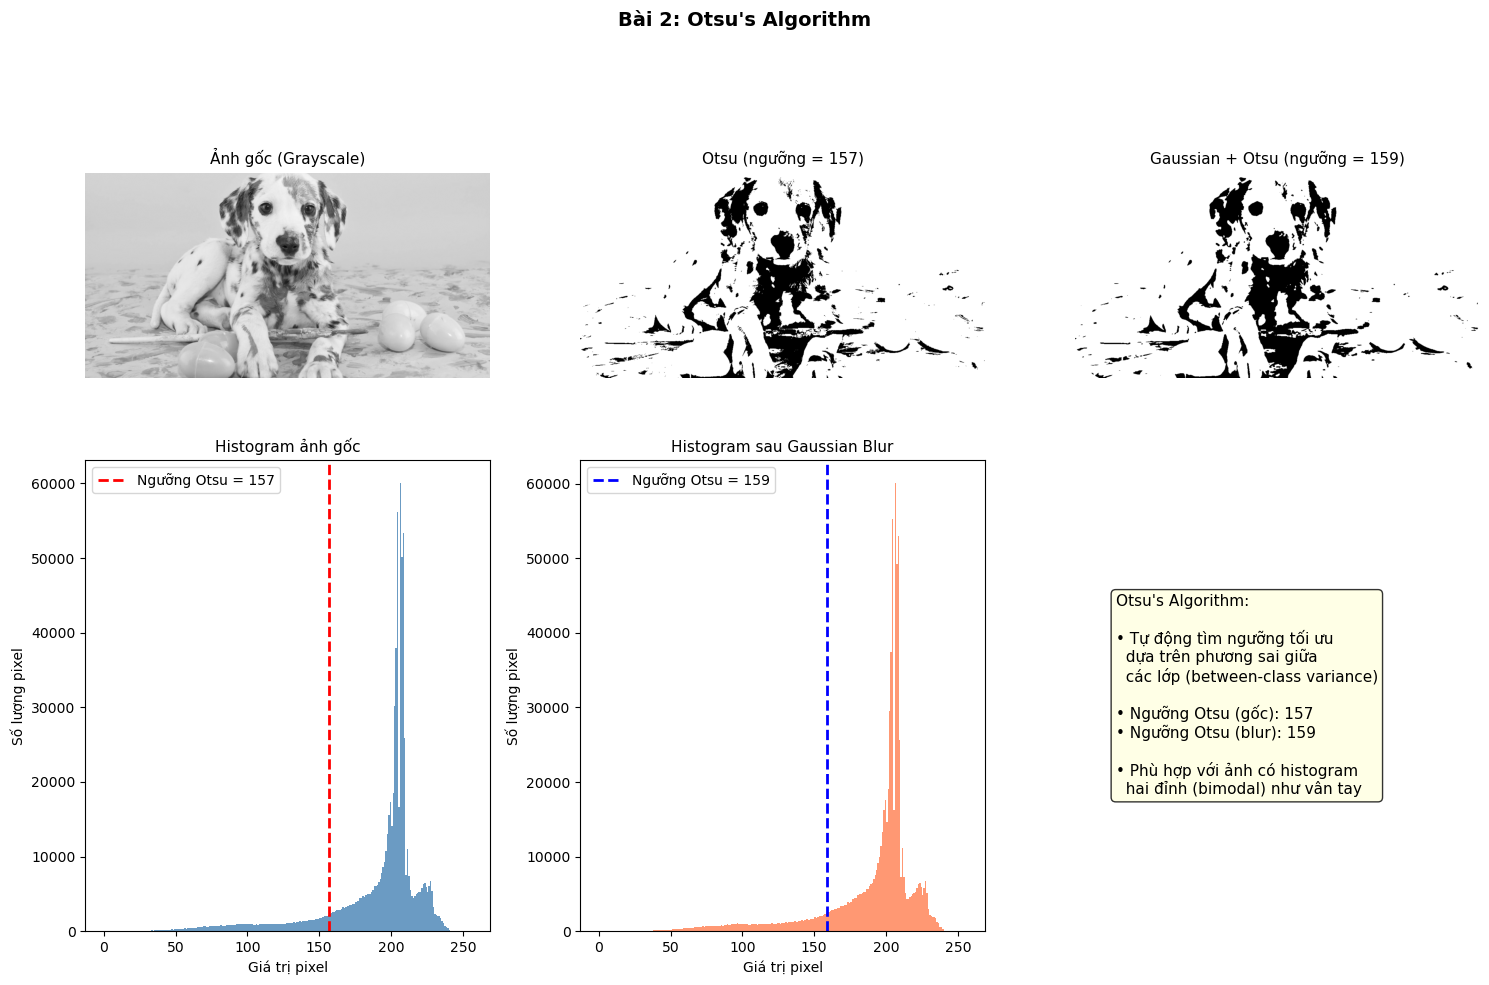

In [7]:
# Otsu's thresholding (tự tìm ngưỡng tối ưu)
otsu_thresh_val, thresh_otsu = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Otsu sau khi lọc Gaussian (giảm nhiễu trước)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
otsu_thresh_val2, thresh_otsu_blur = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Vẽ histogram để minh họa ngưỡng Otsu
hnat.figure(figsize=(15, 10))

# Hàng 1: ảnh
hnat.subplot(2, 3, 1)
hnat.imshow(gray, cmap='gray')
hnat.title('Ảnh gốc (Grayscale)', fontsize=11)
hnat.axis('off')

hnat.subplot(2, 3, 2)
hnat.imshow(thresh_otsu, cmap='gray')
hnat.title(f'Otsu (ngưỡng = {otsu_thresh_val:.0f})', fontsize=11)
hnat.axis('off')

hnat.subplot(2, 3, 3)
hnat.imshow(thresh_otsu_blur, cmap='gray')
hnat.title(f'Gaussian + Otsu (ngưỡng = {otsu_thresh_val2:.0f})', fontsize=11)
hnat.axis('off')

# Hàng 2: histogram
hnat.subplot(2, 3, 4)
hnat.hist(gray.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
hnat.axvline(x=otsu_thresh_val, color='red', linestyle='--', linewidth=2,
               label=f'Ngưỡng Otsu = {otsu_thresh_val:.0f}')
hnat.title('Histogram ảnh gốc', fontsize=11)
hnat.xlabel('Giá trị pixel')
hnat.ylabel('Số lượng pixel')
hnat.legend()

hnat.subplot(2, 3, 5)
hnat.hist(blur.ravel(), bins=256, range=(0, 256), color='coral', alpha=0.8)
hnat.axvline(x=otsu_thresh_val2, color='blue', linestyle='--', linewidth=2,
               label=f'Ngưỡng Otsu = {otsu_thresh_val2:.0f}')
hnat.title('Histogram sau Gaussian Blur', fontsize=11)
hnat.xlabel('Giá trị pixel')
hnat.ylabel('Số lượng pixel')
hnat.legend()

hnat.subplot(2, 3, 6)
hnat.axis('off')
info = (
    f"Otsu's Algorithm:\n\n"
    f"• Tự động tìm ngưỡng tối ưu\n"
    f"  dựa trên phương sai giữa\n"
    f"  các lớp (between-class variance)\n\n"
    f"• Ngưỡng Otsu (gốc): {otsu_thresh_val:.0f}\n"
    f"• Ngưỡng Otsu (blur): {otsu_thresh_val2:.0f}\n\n"
    f"• Phù hợp với ảnh có histogram\n"
    f"  hai đỉnh (bimodal) như vân tay"
)
hnat.text(0.1, 0.5, info, transform=hnat.gca().transAxes,
            fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

hnat.suptitle("Bài 2: Otsu's Algorithm", fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Bài 3: Clustering – K-Means Clustering

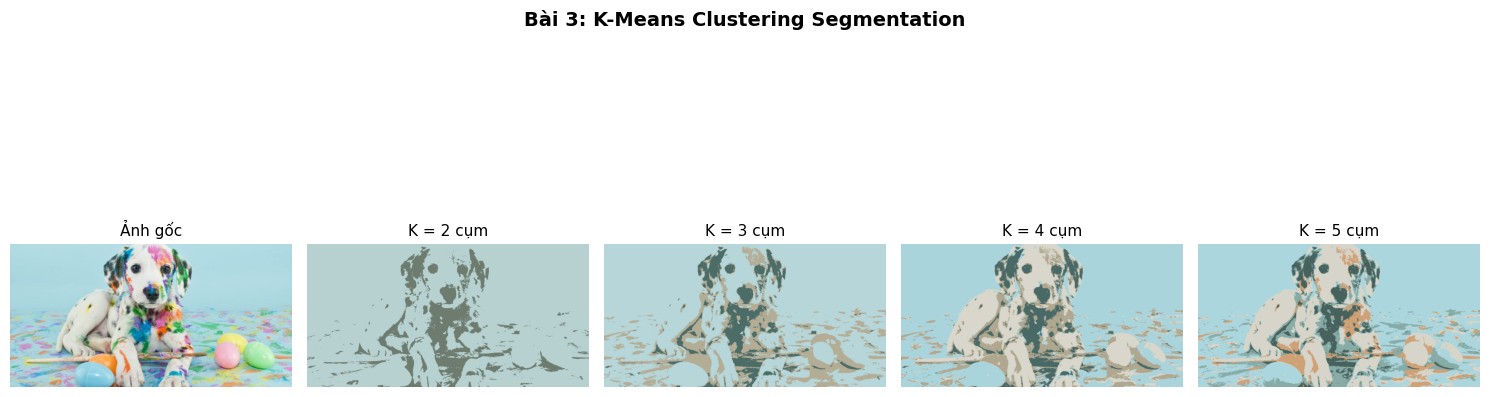

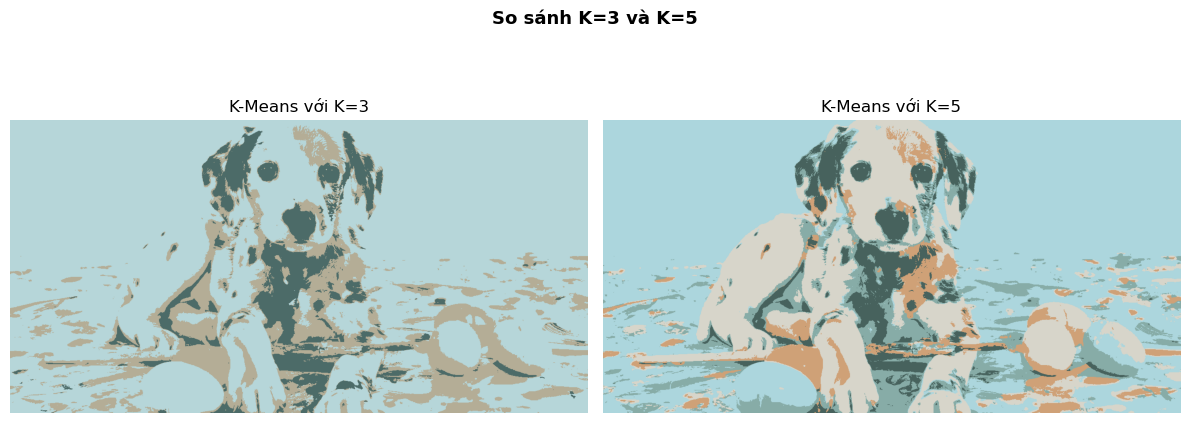

In [8]:
def kmeans_segment(image_bgr, k):
    """Phân đoạn ảnh bằng K-Means với k cụm."""
    # Reshape ảnh thành mảng 2D (pixels x channels)
    pixel_vals = image_bgr.reshape((-1, 3)).astype(np.float32)

    # Tiêu chí dừng: eps=0.2 hoặc sau 100 vòng lặp
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

    # Chạy K-Means
    _, labels, centers = cv2.kmeans(
        pixel_vals, k, None, criteria,
        attempts=10, flags=cv2.KMEANS_RANDOM_CENTERS
    )

    # Gán màu trung tâm cụm về lại từng pixel
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()]
    segmented = segmented.reshape(image_bgr.shape)
    return cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

# Thử với K = 2, 3, 4, 5
k_values = [2, 3, 4, 5]
results = [kmeans_segment(img, k) for k in k_values]

hnat.figure(figsize=(15, 6))

hnat.subplot(1, 5, 1)
hnat.imshow(img_rgb)
hnat.title('Ảnh gốc', fontsize=11)
hnat.axis('off')

for i, (k, result) in enumerate(zip(k_values, results)):
    hnat.subplot(1, 5, i + 2)
    hnat.imshow(result)
    hnat.title(f'K = {k} cụm', fontsize=11)
    hnat.axis('off')

hnat.suptitle('Bài 3: K-Means Clustering Segmentation', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

# So sánh K=3 và K=5 chi tiết
hnat.figure(figsize=(12, 5))
for idx, k in enumerate([3, 5]):
    seg = kmeans_segment(img, k)
    hnat.subplot(1, 2, idx + 1)
    hnat.imshow(seg)
    hnat.title(f'K-Means với K={k}', fontsize=12)
    hnat.axis('off')
hnat.suptitle('So sánh K=3 và K=5', fontsize=13, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Bài 4: Region Growing Algorithm

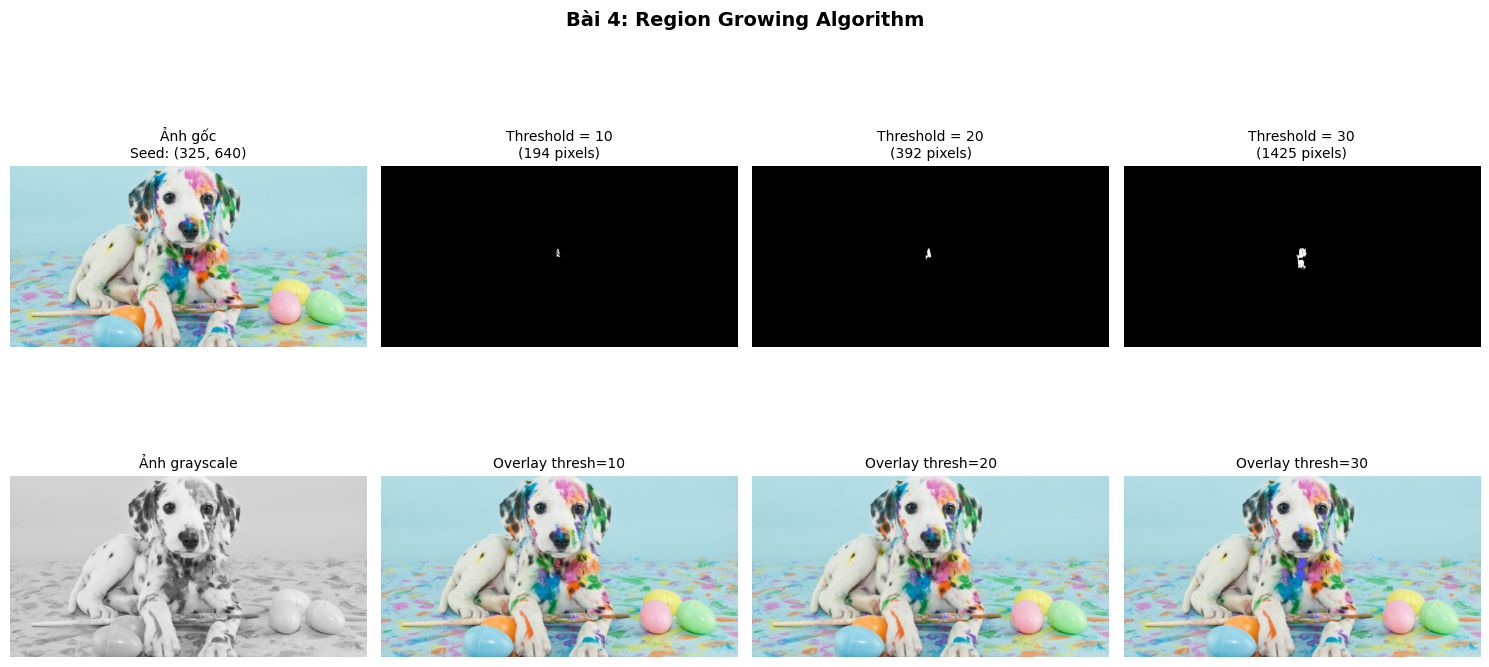

In [9]:
def region_growing(image_gray, seed, threshold=15):
    """
    Thuật toán Region Growing.
    - image_gray: ảnh grayscale (numpy array)
    - seed: tuple (row, col) – điểm khởi đầu
    - threshold: ngưỡng sai khác cường độ để chấp nhận pixel láng giềng
    """
    h, w = image_gray.shape
    visited = np.zeros((h, w), dtype=bool)
    region  = np.zeros((h, w), dtype=np.uint8)

    seed_val = int(image_gray[seed[0], seed[1]])
    queue = [seed]
    visited[seed[0], seed[1]] = True

    # 8-connected neighbors
    neighbors = [(-1,-1),(-1,0),(-1,1),
                 ( 0,-1),        ( 0,1),
                 ( 1,-1),( 1,0),( 1,1)]

    while queue:
        r, c = queue.pop(0)
        region[r, c] = 255

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and not visited[nr, nc]:
                visited[nr, nc] = True
                pixel_val = int(image_gray[nr, nc])
                if abs(pixel_val - seed_val) <= threshold:
                    queue.append((nr, nc))

    return region

# Chọn seed point ở trung tâm ảnh
h, w = gray.shape
seed_center = (h // 2, w // 2)
seed_topleft = (h // 4, w // 4)

# Thử với các ngưỡng khác nhau
thresholds = [10, 20, 30]
regions = [region_growing(gray, seed_center, t) for t in thresholds]

hnat.figure(figsize=(15, 8))

# Hàng 1: ảnh gốc với seed point
hnat.subplot(2, 4, 1)
img_with_seed = img_rgb.copy()
cv2.circle(img_with_seed, (seed_center[1], seed_center[0]), 8, (255, 0, 0), -1)
hnat.imshow(img_with_seed)
hnat.title(f'Ảnh gốc\nSeed: {seed_center}', fontsize=10)
hnat.axis('off')

for i, (t, region) in enumerate(zip(thresholds, regions)):
    pixel_count = np.sum(region > 0)
    hnat.subplot(2, 4, i + 2)
    hnat.imshow(region, cmap='gray')
    hnat.title(f'Threshold = {t}\n({pixel_count} pixels)', fontsize=10)
    hnat.axis('off')

# Hàng 2: overlay vùng lên ảnh gốc
hnat.subplot(2, 4, 5)
hnat.imshow(gray, cmap='gray')
hnat.title('Ảnh grayscale', fontsize=10)
hnat.axis('off')

colors_overlay = ['Reds', 'Greens', 'Blues']
for i, (t, region, cmap) in enumerate(zip(thresholds, regions, colors_overlay)):
    overlay = img_rgb.copy()
    mask = region > 0
    overlay[mask] = [255, 80, 80] if i == 0 else ([80, 200, 80] if i == 1 else [80, 80, 255])
    hnat.subplot(2, 4, i + 6)
    hnat.imshow(overlay)
    hnat.title(f'Overlay thresh={t}', fontsize=10)
    hnat.axis('off')

hnat.suptitle('Bài 4: Region Growing Algorithm', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Bài 5: Split and Merge Algorithm

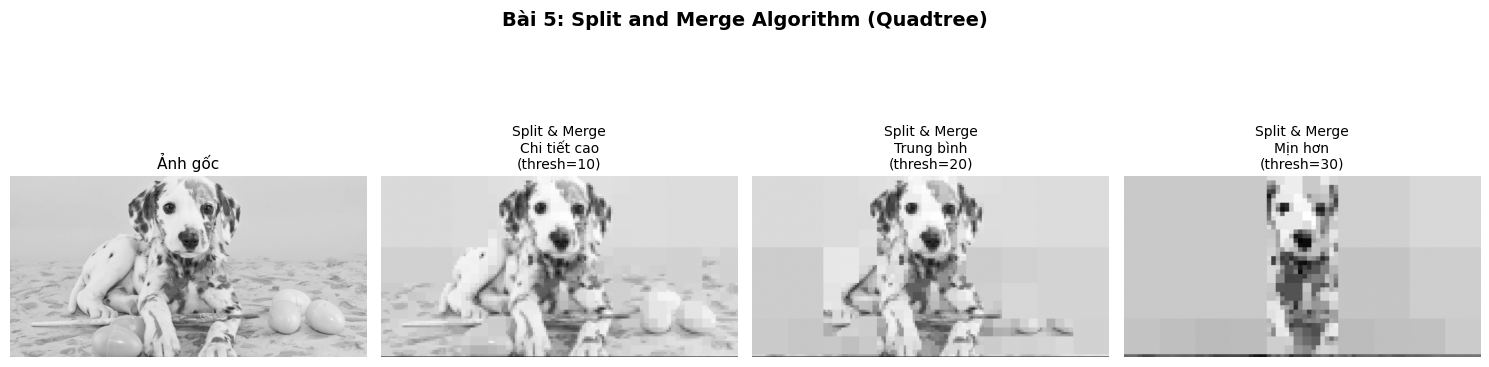

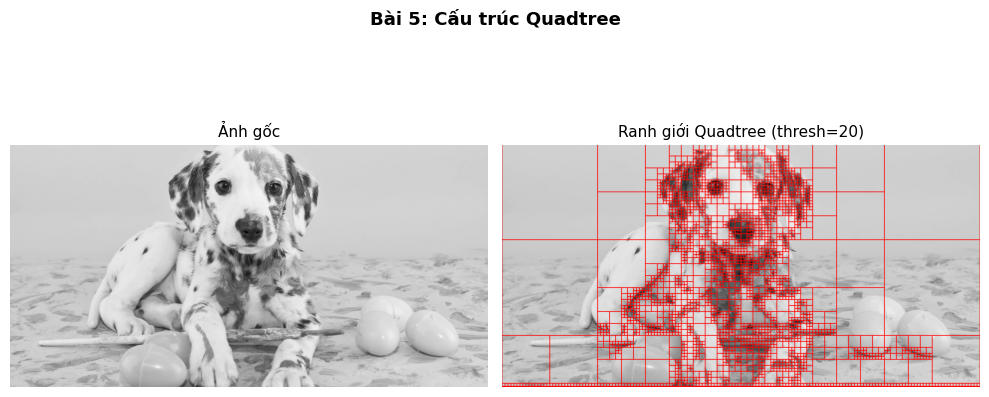

In [10]:
def split_and_merge(image_gray, min_size=8, homogeneity_thresh=15):
    """
    Thuật toán Split and Merge dùng Quadtree.
    - min_size: kích thước tối thiểu của khối (pixels)
    - homogeneity_thresh: std dev tối đa để coi vùng là đồng nhất
    """
    h, w = image_gray.shape
    # Đảm bảo ảnh vuông (pad nếu cần)
    size = max(h, w)
    size = 2 ** int(np.ceil(np.log2(size)))  # lũy thừa 2 gần nhất
    padded = np.zeros((size, size), dtype=np.float32)
    padded[:h, :w] = image_gray

    result = np.zeros((size, size), dtype=np.float32)

    def split(r, c, s):
        block = padded[r:r+s, c:c+s]
        if s <= min_size or block.std() <= homogeneity_thresh:
            # Vùng đồng nhất: gán giá trị trung bình
            result[r:r+s, c:c+s] = block.mean()
        else:
            # Chia thành 4 quadrant
            half = s // 2
            split(r,        c,        half)
            split(r,        c + half, half)
            split(r + half, c,        half)
            split(r + half, c + half, half)

    split(0, 0, size)
    return np.uint8(result[:h, :w])

# Áp dụng với các tham số khác nhau
params = [
    (8,  10, 'Chi tiết cao\n(thresh=10)'),
    (8,  20, 'Trung bình\n(thresh=20)'),
    (16, 30, 'Mịn hơn\n(thresh=30)'),
]

results_sm = [split_and_merge(gray, min_s, t) for min_s, t, _ in params]

hnat.figure(figsize=(15, 5))

hnat.subplot(1, 4, 1)
hnat.imshow(gray, cmap='gray')
hnat.title('Ảnh gốc', fontsize=11)
hnat.axis('off')

for i, (result_sm, (_, _, label)) in enumerate(zip(results_sm, params)):
    hnat.subplot(1, 4, i + 2)
    hnat.imshow(result_sm, cmap='gray')
    hnat.title(f'Split & Merge\n{label}', fontsize=10)
    hnat.axis('off')

hnat.suptitle('Bài 5: Split and Merge Algorithm (Quadtree)', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

# Hiển thị ranh giới quadtree
def draw_quadtree_borders(image_gray, min_size=8, thresh=20):
    h, w = image_gray.shape
    size = 2 ** int(np.ceil(np.log2(max(h, w))))
    padded = np.zeros((size, size), dtype=np.float32)
    padded[:h, :w] = image_gray
    border_img = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

    def draw(r, c, s):
        block = padded[r:r+s, c:c+s]
        if s <= min_size or block.std() <= thresh:
            rr, cc = min(r, h-1), min(c, w-1)
            re, ce = min(r+s, h)-1, min(c+s, w)-1
            cv2.rectangle(border_img, (cc, rr), (ce, re), (255, 0, 0), 1)
        else:
            half = s // 2
            draw(r, c, half); draw(r, c+half, half)
            draw(r+half, c, half); draw(r+half, c+half, half)

    draw(0, 0, size)
    return border_img

border = draw_quadtree_borders(gray, min_size=8, thresh=20)

hnat.figure(figsize=(10, 5))
hnat.subplot(1, 2, 1)
hnat.imshow(gray, cmap='gray')
hnat.title('Ảnh gốc', fontsize=11)
hnat.axis('off')
hnat.subplot(1, 2, 2)
hnat.imshow(border)
hnat.title('Ranh giới Quadtree (thresh=20)', fontsize=11)
hnat.axis('off')
hnat.suptitle('Bài 5: Cấu trúc Quadtree', fontsize=13, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Bài 6: Edge-Based Segmentation

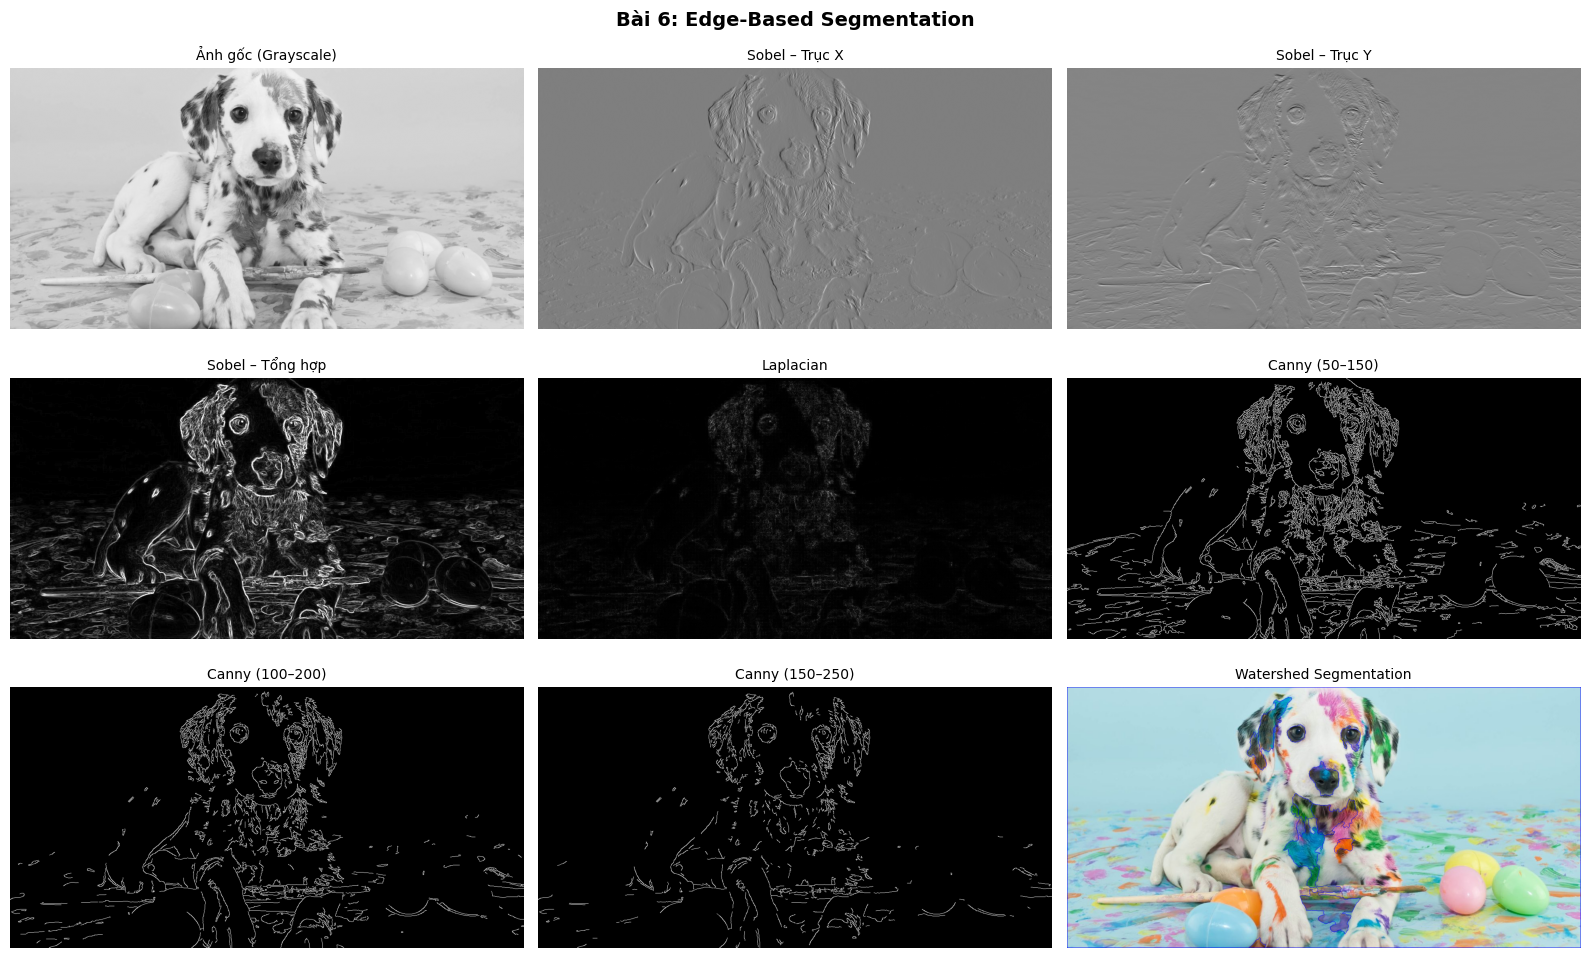

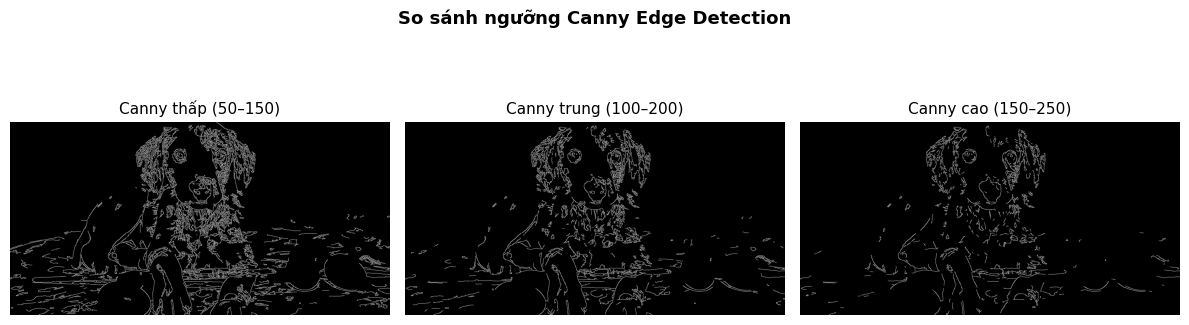

In [11]:
# 1. Sobel – phát hiện gradient theo X và Y
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

# 2. Laplacian – phát hiện cạnh qua đạo hàm bậc 2
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))

# 3. Canny – phát hiện cạnh tối ưu (Canny, 1986)
canny_low  = cv2.Canny(gray, 50,  150)
canny_mid  = cv2.Canny(gray, 100, 200)
canny_high = cv2.Canny(gray, 150, 250)

# 4. Watershed segmentation (kết hợp Canny + Watershed)
def watershed_segment(image_bgr):
    gray_ws = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    # Threshold để xác định vùng chắc chắn
    _, thresh_ws = cv2.threshold(gray_ws, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Morphology để loại nhiễu
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh_ws, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg  = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg  = np.uint8(sure_fg)
    unknown  = cv2.subtract(sure_bg, sure_fg)
    # Markers
    _, markers = cv2.connectedComponents(sure_fg)
    markers    = markers + 1
    markers[unknown == 255] = 0
    markers = cv2.watershed(image_bgr, markers)
    result  = image_bgr.copy()
    result[markers == -1] = [255, 0, 0]  # tô đỏ ranh giới
    return cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

watershed_result = watershed_segment(img)

# --- Hiển thị ---
hnat.figure(figsize=(16, 10))

subplot_data = [
    (gray,             'gray',  'Ảnh gốc (Grayscale)'),
    (sobelx,           'gray',  'Sobel – Trục X'),
    (sobely,           'gray',  'Sobel – Trục Y'),
    (sobel_combined,   'gray',  'Sobel – Tổng hợp'),
    (laplacian_abs,    'gray',  'Laplacian'),
    (canny_low,        'gray',  'Canny (50–150)'),
    (canny_mid,        'gray',  'Canny (100–200)'),
    (canny_high,       'gray',  'Canny (150–250)'),
    (watershed_result, None,    'Watershed Segmentation'),
]

for i, (image, cmap, title) in enumerate(subplot_data):
    hnat.subplot(3, 3, i + 1)
    if cmap:
        hnat.imshow(image, cmap=cmap)
    else:
        hnat.imshow(image)
    hnat.title(title, fontsize=10)
    hnat.axis('off')

hnat.suptitle('Bài 6: Edge-Based Segmentation', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

# So sánh 3 phương pháp Canny
hnat.figure(figsize=(12, 4))
for idx, (canny_img, label) in enumerate(zip(
        [canny_low, canny_mid, canny_high],
        ['Canny thấp (50–150)', 'Canny trung (100–200)', 'Canny cao (150–250)'])):
    hnat.subplot(1, 3, idx + 1)
    hnat.imshow(canny_img, cmap='gray')
    hnat.title(label, fontsize=11)
    hnat.axis('off')
hnat.suptitle('So sánh ngưỡng Canny Edge Detection', fontsize=13, fontweight='bold')
hnat.tight_layout()
hnat.show()